# ETS (exponential smoothing)

ETS models describe a series through slowly evolving *states* — level, optional trend, optional seasonality — updated by exponential smoothing. The error/trend/season taxonomy spans 30 variants (additive or multiplicative, damped or not), so a single generator covers a broad family of realistic trend-plus-seasonality shapes.

::: {.callout-note}
## The model

$$y_t = \mu_t + \varepsilon_t, \qquad \mu_t = \ell_{t-1} + \phi\, b_{t-1} + s_{t-m} \quad \text{(ETS(A,A,A))}$$

Each series is built from a level state plus optional trend and seasonal states, combined additively or multiplicatively via `error_type`, `trend_type`, `seasonal_type`, and `damped`. This is the state-space form behind Holt and Holt-Winters smoothing.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import ETSGenerator

## 1. Taxonomy variants

The error/trend/season triple selects the model. All three draws share a seed, a starting level, and a seasonal period, so the shapes differ only by taxonomy: a damped additive trend flattens out, a multiplicative season grows with the level, and no trend or season leaves pure level smoothing.


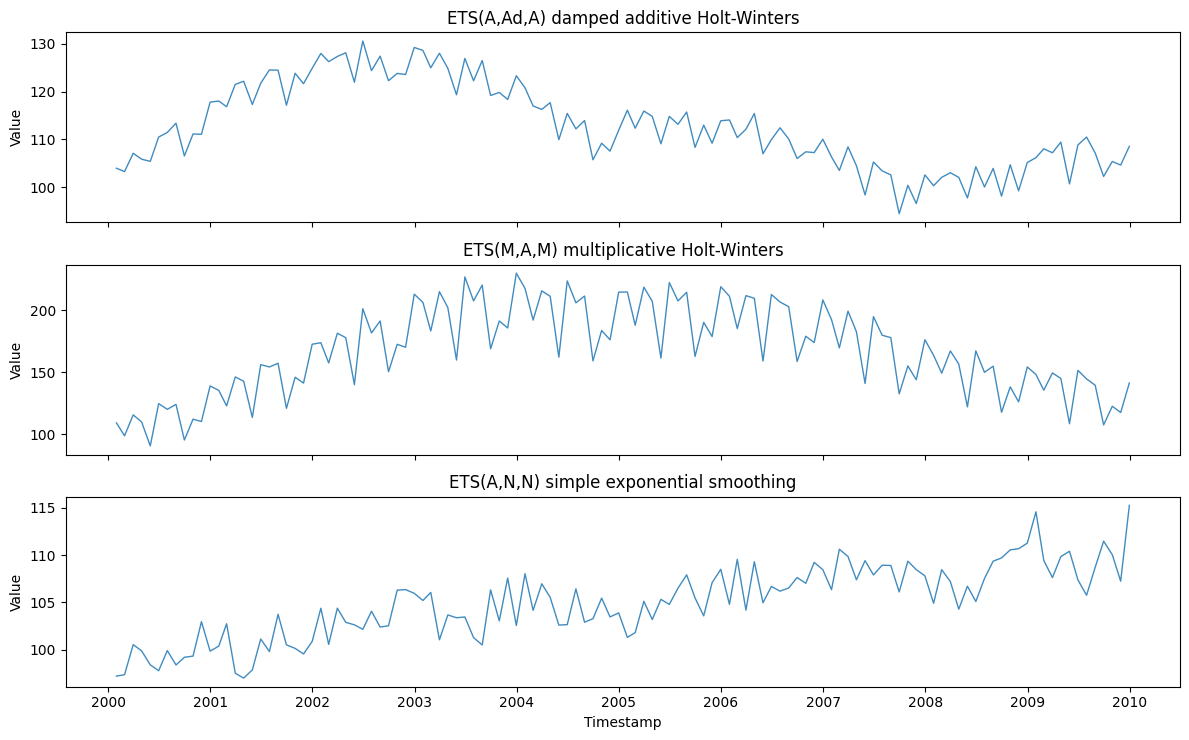

In [ ]:
damped_df = ETSGenerator(
    engine="polars", min_length=120, max_length=120, freq="ME",
    error_type="add", trend_type="add", seasonal_type="add", damped=True, phi=0.9,
    seasonal_period=12, level=100.0, trend=1.0, noise_std=2.0, seed=42,
).generate(n_series=1)

multiplicative_df = ETSGenerator(
    engine="polars", min_length=120, max_length=120, freq="ME",
    error_type="mul", trend_type="add", seasonal_type="mul",
    seasonal_period=12, level=100.0, trend=1.0, noise_std=0.02, seed=42,
).generate(n_series=1)

level_only_df = ETSGenerator(
    engine="polars", min_length=120, max_length=120, freq="ME",
    error_type="add", trend_type=None, seasonal_type=None,
    level=100.0, noise_std=2.0, seed=42,
).generate(n_series=1)

panels = [
    ("ETS(A,Ad,A) damped additive Holt-Winters", damped_df),
    ("ETS(M,A,M) multiplicative Holt-Winters", multiplicative_df),
    ("ETS(A,N,N) simple exponential smoothing", level_only_df),
]
fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True)
for ax, (label, df) in zip(axes, panels):
    ax.plot(df["ds"].to_list(), df["y"].to_list(), alpha=0.85, linewidth=1)
    ax.set(ylabel="Value", title=label)
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


## 2. State export

Generate data and extract the underlying level, trend, and seasonal state components.

In [ ]:
params_states = {
    "min_length": 50,
    "max_length": 50,
    "freq": "D",
    "error_type": "add",
    "trend_type": "add",
    "seasonal_type": "add",
    "seasonal_period": 7,
    "level": 100.0,
    "trend": 1.0,
    "alpha": 0.3,
    "beta": 0.1,
    "gamma": 0.1,
    "noise_std": 1.0,
    "seed": 42,
}

generator_states = ETSGenerator(engine="polars", **params_states)
obs_df, states_df = generator_states.generate_with_states(n_series=1)

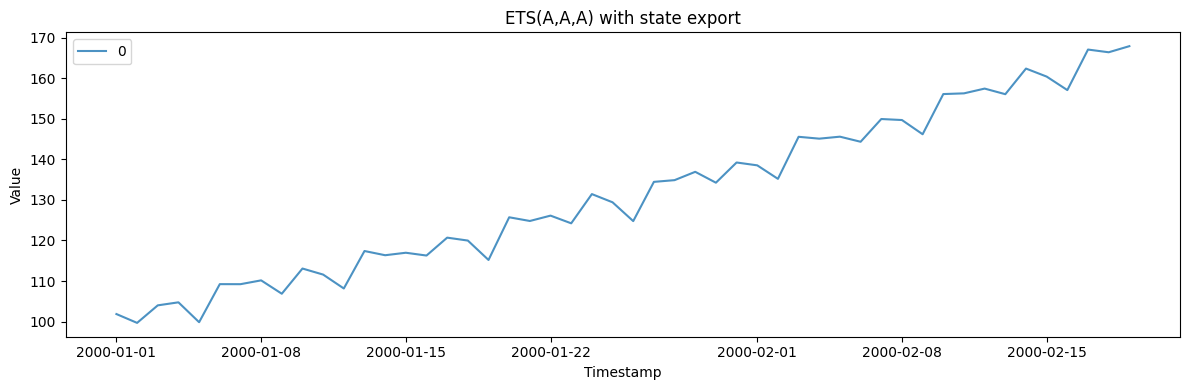

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in obs_df["unique_id"].unique().to_list():
    series = obs_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("ETS(A,A,A) with state export")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Observations DataFrame:")
obs_df.head(10)

Observations DataFrame:


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,101.852261
"""0""",2000-01-02 00:00:00,99.674429
"""0""",2000-01-03 00:00:00,103.997037
"""0""",2000-01-04 00:00:00,104.742658
"""0""",2000-01-05 00:00:00,99.842295
"""0""",2000-01-06 00:00:00,109.225432
"""0""",2000-01-07 00:00:00,109.215338
"""0""",2000-01-08 00:00:00,110.156755
"""0""",2000-01-09 00:00:00,106.862563


In [ ]:
print("States DataFrame (level, trend, seasonal components):")
states_df.head(10)

States DataFrame (level, trend, seasonal components):


unique_id,ds,level,trend,seasonal_0,seasonal_1,seasonal_2,seasonal_3,seasonal_4,seasonal_5,seasonal_6
cat,datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,f64
"""0""",2000-01-01 00:00:00,100.0,1.0,1.168504,-2.182273,2.014922,0.402623,-5.629283,3.185167,1.04034
"""0""",2000-01-02 00:00:00,100.905127,0.968376,1.136879,-2.182273,2.014922,0.402623,-5.629283,3.185167,1.04034
"""0""",2000-01-03 00:00:00,101.868463,0.966696,1.136879,-2.183953,2.014922,0.402623,-5.629283,3.185167,1.04034
"""0""",2000-01-04 00:00:00,102.579245,0.881391,1.136879,-2.183953,1.929618,0.402623,-5.629283,3.185167,1.04034
"""0""",2000-01-05 00:00:00,103.724456,0.969331,1.136879,-2.183953,1.929618,0.490563,-5.629283,3.185167,1.04034
"""0""",2000-01-06 00:00:00,104.927124,1.04711,1.136879,-2.183953,1.929618,0.490563,-5.551504,3.185167,1.04034
"""0""",2000-01-07 00:00:00,105.994044,1.053713,1.136879,-2.183953,1.929618,0.490563,-5.551504,3.19177,1.04034
"""0""",2000-01-08 00:00:00,107.385929,1.166437,1.136879,-2.183953,1.929618,0.490563,-5.551504,3.19177,1.153064
"""0""",2000-01-09 00:00:00,108.69262,1.213188,1.18363,-2.183953,1.929618,0.490563,-5.551504,3.19177,1.153064


## 3. Box-Cox transformation

Apply a Box-Cox transformation (lambda=0.5, square root) to the generated series.

In [ ]:
params_boxcox = {
    "min_length": 100,
    "max_length": 100,
    "freq": "D",
    "error_type": "add",
    "trend_type": "add",
    "seasonal_type": None,
    "level": 100.0,
    "trend": 0.5,
    "alpha": 0.3,
    "beta": 0.1,
    "noise_std": 0.5,
    "box_cox_lambda": 0.5,
    "seed": 111,
}

generator_boxcox = ETSGenerator(engine="polars", **params_boxcox)
df_boxcox = generator_boxcox.generate(n_series=1)

print(f"Model: {generator_boxcox.get_model_info()['model']}")
print(f"Box-Cox lambda: {generator_boxcox.get_model_info()['box_cox_lambda']}")
print(f"Mean: {df_boxcox['y'].mean():.2f}")
print(f"Std: {df_boxcox['y'].std():.2f}")

Model: ETS(A,A,N)
Box-Cox lambda: 0.5
Mean: 115.15
Std: 5.02


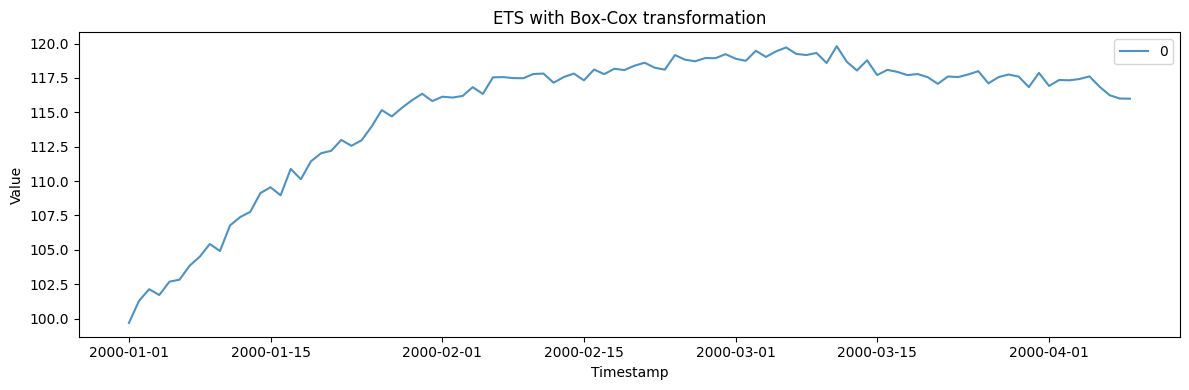

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_boxcox["unique_id"].unique().to_list():
    series = df_boxcox.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("ETS with Box-Cox transformation")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [SARIMA](/synforecast/docs/generators/statistical/sarima.html) — the ARIMA view of the same trend/seasonal structure.
- [Seasonal](/synforecast/docs/generators/statistical/seasonal.html) — a fixed seasonal wave when you don't need evolving states.

The full error/trend/season taxonomy is in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::